In [1]:
!module list

Currently Loaded Modulefiles:
 1) singularity   2) openmpi/4.1.5   3) NCI-ai-ml/24.08   4) pbs  
>

In [2]:
from math import ceil
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import sys,os,time
wdir1="/g/data/z00/yxs900/neuraloperators/sfno/curriculum_learning/lowRes/experiments/05_LUCIE_rm_pos_embed/"
sys.path.append(wdir1)
from torch_harmonics_local_v2 import *


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    
device

device(type='cuda', index=0)

In [7]:
# prepare the autoregressive dataset
from torch.utils.data import DataLoader
nb_dir="/g/data/z00/yxs900/neuraloperators/sfno/curriculum_learning/lowRes/experiments/061_LUCIE_no_pos_embed_wb1.4"
sys.path.append(nb_dir)
from datasets_res import WBDataset


ddir = "/g/data/wb00/admin/testing/t_WeatherBench"
dpth_str = f"{ddir}/a_wb2*.nc"
cpth = f"{ddir}/constants_1.40625deg.nc"

didir = "/g/data/z00/yxs900/neuraloperators/sfno/curriculum_learning/lowRes/experiments/061_LUCIE_no_pos_embed_wb1.4/datasets"
mpth = f"{didir}/all_means.npy"
spth = f"{didir}/all_stds.npy"
rpth = f"{didir}/all_res0.npy"
    
avs = ["tisr","t1000","t850","q1000","q850","u500","u200","v500","v200","sp","log_tp"]
vs_in = ["tisr","t850","q850","u500","v500","sp"]
vs_out = ["t850","q850","u500","v500","sp","log_tp"]
iidx = [avs.index(vi) for vi in vs_in]
oidx = [avs.index(vi) for vi in vs_out]
vc = ["lat2d","lon2d","orography"]
nsamples = 87600 # 10y hourly
idx_start = 3
nworkers = 10

samples = WBDataset(dpth_str,cpth,in_chans=vs_in, out_chans=vs_out, const_chans=vc, norm_paths=[mpth,spth,rpth],iidx=iidx, oidx=oidx, nsamples=nsamples)
v = torch.utils.data.Subset(samples,list(range(idx_start,nsamples,6)))
vdl = DataLoader(v, shuffle=False, batch_size=1, num_workers=nworkers,drop_last=True)

v.indices[:10], len(v.indices), len(vdl)

([3, 9, 15, 21, 27, 33, 39, 45, 51, 57], 14600, 14600)

In [8]:
# prep for plotting.

# read in lat, lon grid
from netCDF4 import Dataset as ncDataset
with ncDataset(cpth, 'r') as ds:
    Lat= ds['lat2d'][:].data
    Lon= ds['lon2d'][:].data

# set figure size
w,h = 5,4
vars = vs_out
nvars=len(vars)

In [9]:
Lat.shape

(128, 256)

In [11]:
# load the best RMSE trained model 
nlat, nlon = Lat.shape

n_in_channels = len(vs_in)+len(vc)
n_out_channels = len(vs_out)

hard_thresholding_fraction = 0.9
model = SphericalFourierNeuralOperatorNet(params = {"data_grid":"equiangular"}, spectral_transform='sht', filter_type = "linear", operator_type='dhconv', img_shape=(nlat, nlon),num_layers=8, in_chans=n_in_channels, out_chans=n_out_channels, scale_factor=1, embed_dim=128, activation_function="silu", big_skip=True, pos_embed=False, use_mlp=True,normalization_layer="instance_norm", hard_thresholding_fraction=hard_thresholding_fraction,mlp_ratio = 2.).to(device)

wdir=f"{nb_dir}"
jobid="145367077"
ei="172"
ckp = torch.load(f'{wdir}/checkpoints/{jobid}.gadi-pbs/lucie_{ei}.pt')
model.load_state_dict(ckp["model_state_dict"])

<All keys matched successfully>

In [12]:
def rollout_model_tisr_forcing(vdl, model, device="cuda"):
    asteps=len(vdl)
    c,h,w = vdl.dataset[0][1].shape
    pred = torch.zeros(asteps,c,h,w)
    targ = torch.zeros(asteps,c,h,w)

    res = torch.tensor(vdl.dataset.dataset.res).to(device)

    model.eval()
    with torch.no_grad():
        for ii, data in enumerate(vdl, 0):
            #print(f"step {ii}, inp shape = {data[0].shape}, tar shape = {data[1].shape}")
            inp, tar = map(lambda x: x.to(device, dtype = torch.float32), data)
            if ii==0:
                prd = inp
            else:
                prd = torch.concatenate((inp[:,:4,:,:], prd[:,:-1,:,:]*res[0,:-1,:,:]),axis=1)

            prd = model(prd)
            pred[ii,:] = prd.cpu()
            targ[ii,:] = tar.cpu()

    return pred,targ

In [13]:
# run the rollout for 10y
pp,tt = rollout_model_tisr_forcing(vdl, model)

# Check the Spatial Pattern

In [14]:
vars = vs_out
nvars=len(vars)

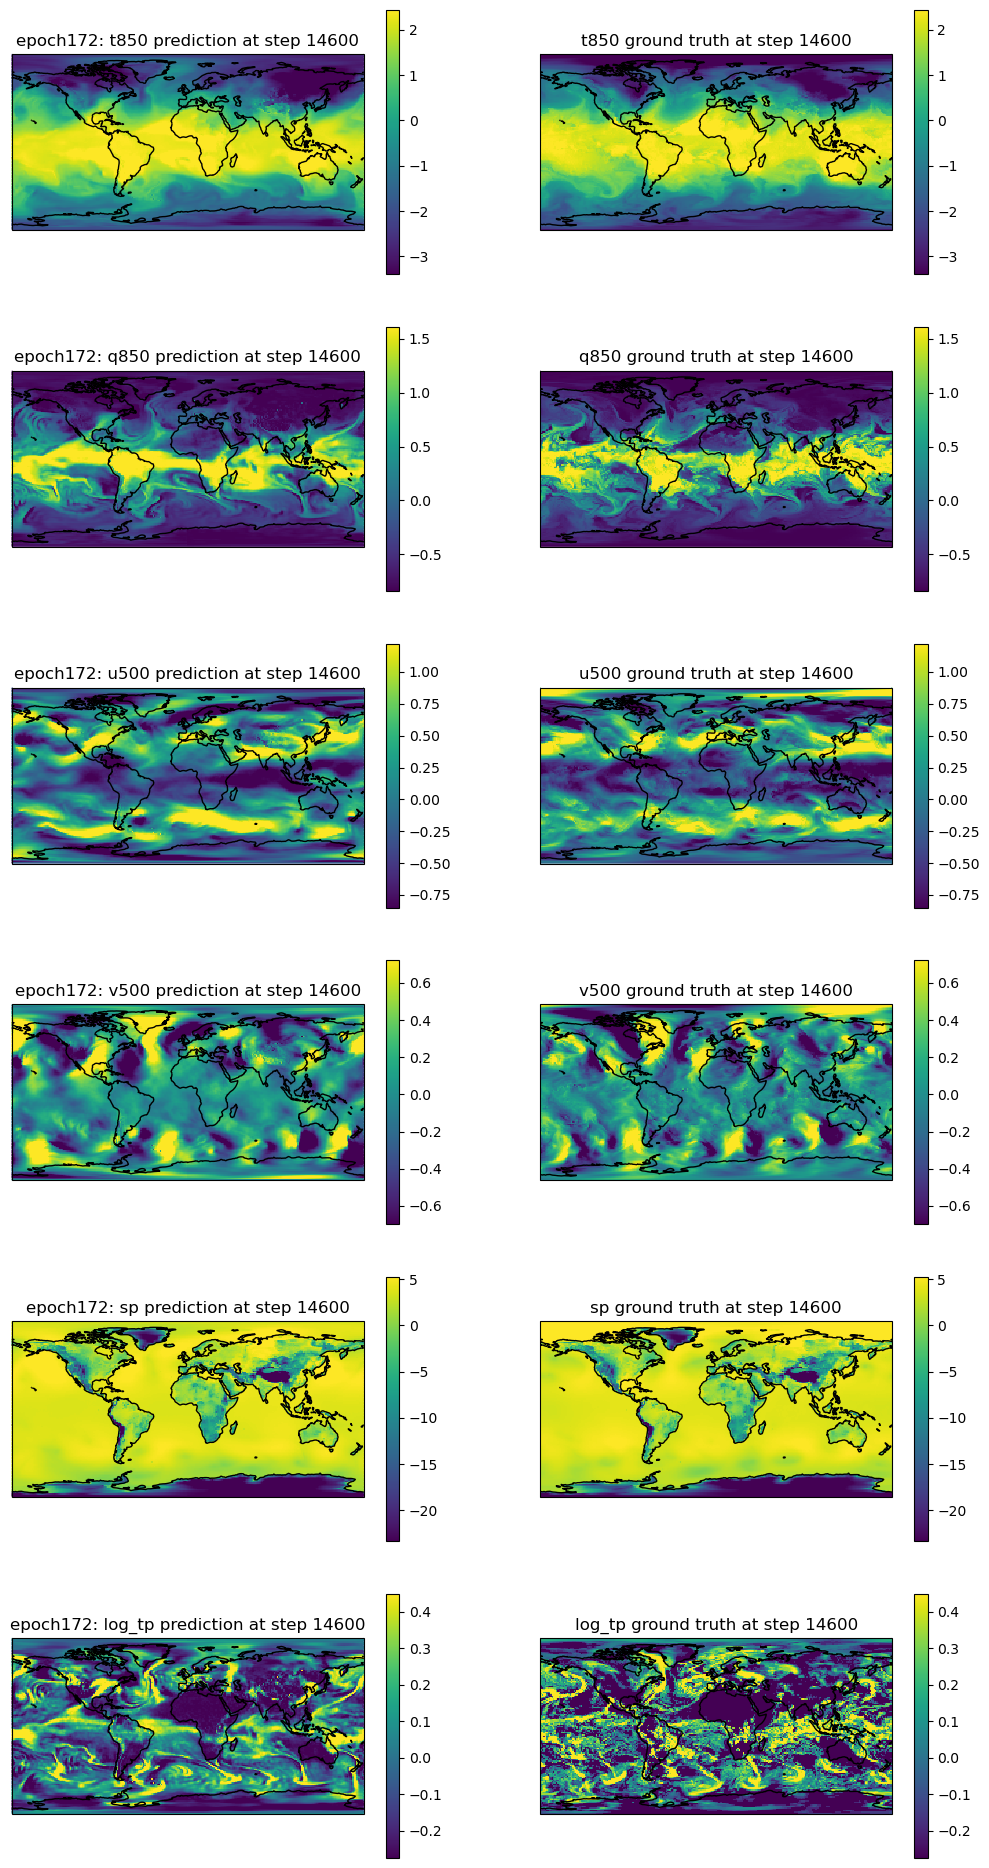

In [15]:
ss = pp.shape[0]
fig,axs = plt.subplots(nvars,2, figsize=(w*2.5,h*nvars),subplot_kw={'projection': ccrs.PlateCarree()},squeeze=False)
for ii in range(nvars):
    pii = pp[ss-1,ii,:,:]
    tii = tt[ss-1,ii,:,:]
    combined_values = np.concatenate([pii.flatten(), tii.flatten()])
    cmin, cmax = np.nanquantile(combined_values, [0.05, 0.95])
        
    pcm = axs[ii,0].pcolormesh(Lon,Lat,pii,vmin=cmin, vmax=cmax,cmap='viridis', shading='auto')
    axs[ii,0].coastlines()
    axs[ii,0].set_title(f"epoch{ei}: {vars[ii]} prediction at step {ss}")
    fig.colorbar(pcm, ax=axs[ii,0])
    
    pcm1 = axs[ii,1].pcolormesh(Lon,Lat,tii,vmin=cmin, vmax=cmax,cmap='viridis', shading='auto')
    axs[ii,1].coastlines()
    axs[ii,1].set_title(f"{vars[ii]} ground truth at step {ss}")
    fig.colorbar(pcm1, ax=axs[ii,1])

# Compare Global Mean over Time

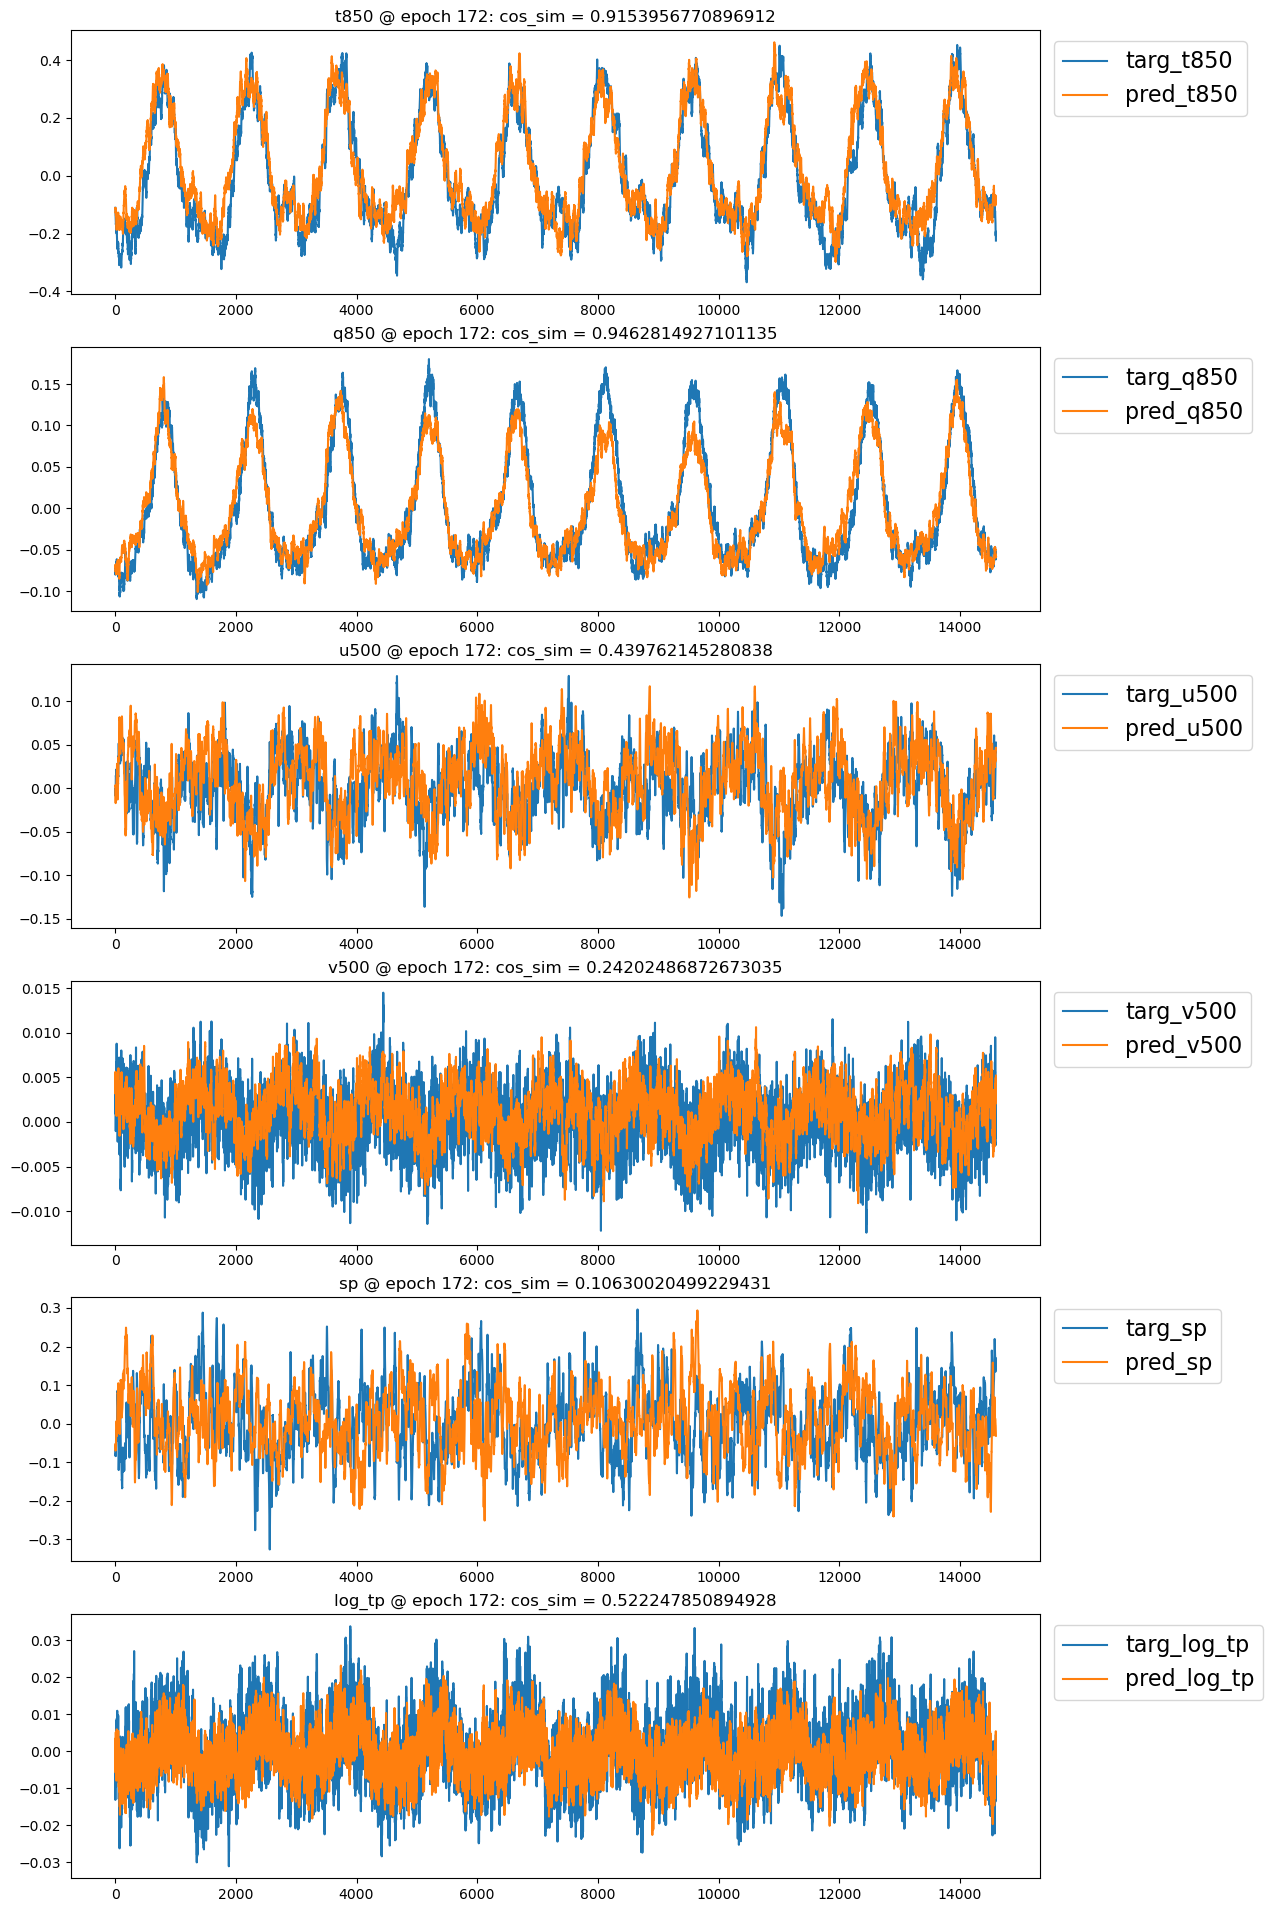

In [16]:
true_clim_t = torch.mean(tt,dim=(-1,-2))
pred_clim_t = torch.mean(pp,dim=(-1,-2))
fig,axs = plt.subplots(nvars,1, figsize=(w*2.5,h*nvars))
for ii in range(nvars):
    pcm1 = axs[ii].plot(true_clim_t[:,ii],label=f"targ_{vars[ii]}")
    pcm2 = axs[ii].plot(pred_clim_t[:,ii],label=f"pred_{vars[ii]}")
    ppi = pred_clim_t[1460:,ii].reshape(1, -1)
    tti = true_clim_t[1460:,ii].reshape(1, -1)
    cos_sim = cosine_similarity(ppi, tti)[0, 0]
    axs[ii].set_title(f"{vars[ii]} @ epoch {ei}: cos_sim = {cos_sim}")
    axs[ii].legend(loc='upper left', bbox_to_anchor=(1.003, 1),fontsize=16)

In [17]:
# 10y mean clim_bias, it is expected to be different from what reported in the training 
print(pp.shape)
true_clim = torch.mean(pp[1460:],dim=0)
pred_clim = torch.mean(tt[1460:],dim=0)

clim_bias = torch.mean(torch.abs(true_clim - pred_clim))
clim_bias

torch.Size([14600, 6, 128, 256])


tensor(0.0822)

In [18]:
#true_clim_t = torch.mean(tt,dim=(-1,-2))
#pred_clim_t = torch.mean(pp,dim=(-1,-2))

print(true_clim_t.shape)
clim_bias_alternative = torch.mean(torch.abs(true_clim_t[1460:] - pred_clim_t[1460:]))
clim_bias_alternative

torch.Size([14600, 6])


tensor(0.0365)

In [19]:
# relative clim_bias by vars
rel_clim_bias = torch.mean(torch.abs((pred_clim - true_clim)/true_clim),dim=(-2,-1))
list(zip(vars,rel_clim_bias.tolist()))

[('t850', 0.3902277946472168),
 ('q850', 0.5290489196777344),
 ('u500', 2.2614517211914062),
 ('v500', 5.529929161071777),
 ('sp', 0.0866105705499649),
 ('log_tp', 1.6989554166793823)]

In [20]:
# relative clim_bias by vars
rel_clim_bias = torch.mean(torch.abs((pred_clim_t[1460:] - true_clim_t[1460:])/true_clim_t[1460:]),dim=0)
list(zip(vars,rel_clim_bias.tolist()))

[('t850', 1.291314959526062),
 ('q850', 2.7338624000549316),
 ('u500', 5.902852535247803),
 ('v500', 5.48508358001709),
 ('sp', 4.965343475341797),
 ('log_tp', 9.572620391845703)]

In [22]:
from scipy.stats import pearsonr

# use pearson correlation to see the scale invariant trend difference?
# it can be offset insensitive
for ii in range(nvars):
    ppi = pred_clim_t[1460:,ii]
    tti = true_clim_t[1460:,ii]
    pearson_corr, p_value = pearsonr(ppi,tti)
    print(f"Pearson correlation coefficient for {vars[ii]}:", pearson_corr)

Pearson correlation coefficient for t850: 0.9252767154147483
Pearson correlation coefficient for q850: 0.9472995736684094
Pearson correlation coefficient for u500: 0.4452575944222537
Pearson correlation coefficient for v500: 0.25830186609743644
Pearson correlation coefficient for sp: 0.10665650855710151
Pearson correlation coefficient for log_tp: 0.5275051812529454


In [23]:
# use cosine similarity to see the scale invariant trend difference?
# it can recongnise both offset and time-shift

from sklearn.metrics.pairwise import cosine_similarity
for ii in range(nvars):
    ppi = pred_clim_t[1460:,ii].reshape(1, -1)
    tti = true_clim_t[1460:,ii].reshape(1, -1)
    cos_sim = cosine_similarity(ppi, tti)[0, 0]
    print(f"Cosine similarity for {vars[ii]}:", cos_sim)

Cosine similarity for t850: 0.9153957
Cosine similarity for q850: 0.9462815
Cosine similarity for u500: 0.43976215
Cosine similarity for v500: 0.24202487
Cosine similarity for sp: 0.106300205
Cosine similarity for log_tp: 0.52224785


# Compare to the Model State saved Earlier

In [27]:
# load the best RMSE trained model after turn on the spectral regulation
nlat, nlon = Lat.shape

n_in_channels = len(vs_in)+len(vc)
n_out_channels = len(vs_out)

hard_thresholding_fraction = 0.9
model = SphericalFourierNeuralOperatorNet(params = {"data_grid":"equiangular"}, spectral_transform='sht', filter_type = "linear", operator_type='dhconv', img_shape=(nlat, nlon),num_layers=8, in_chans=n_in_channels, out_chans=n_out_channels, scale_factor=1, embed_dim=128, activation_function="silu", big_skip=True, pos_embed=False, use_mlp=True,normalization_layer="instance_norm", hard_thresholding_fraction=hard_thresholding_fraction,mlp_ratio = 2.).to(device)

wdir=f"{nb_dir}"
jobid="145367077"
ei="147"
ckp = torch.load(f'{wdir}/checkpoints/{jobid}.gadi-pbs/lucie_{ei}.pt')
model.load_state_dict(ckp["model_state_dict"])

<All keys matched successfully>

In [28]:
# run the rollout for 10y
pp,tt = rollout_model_tisr_forcing(vdl, model)

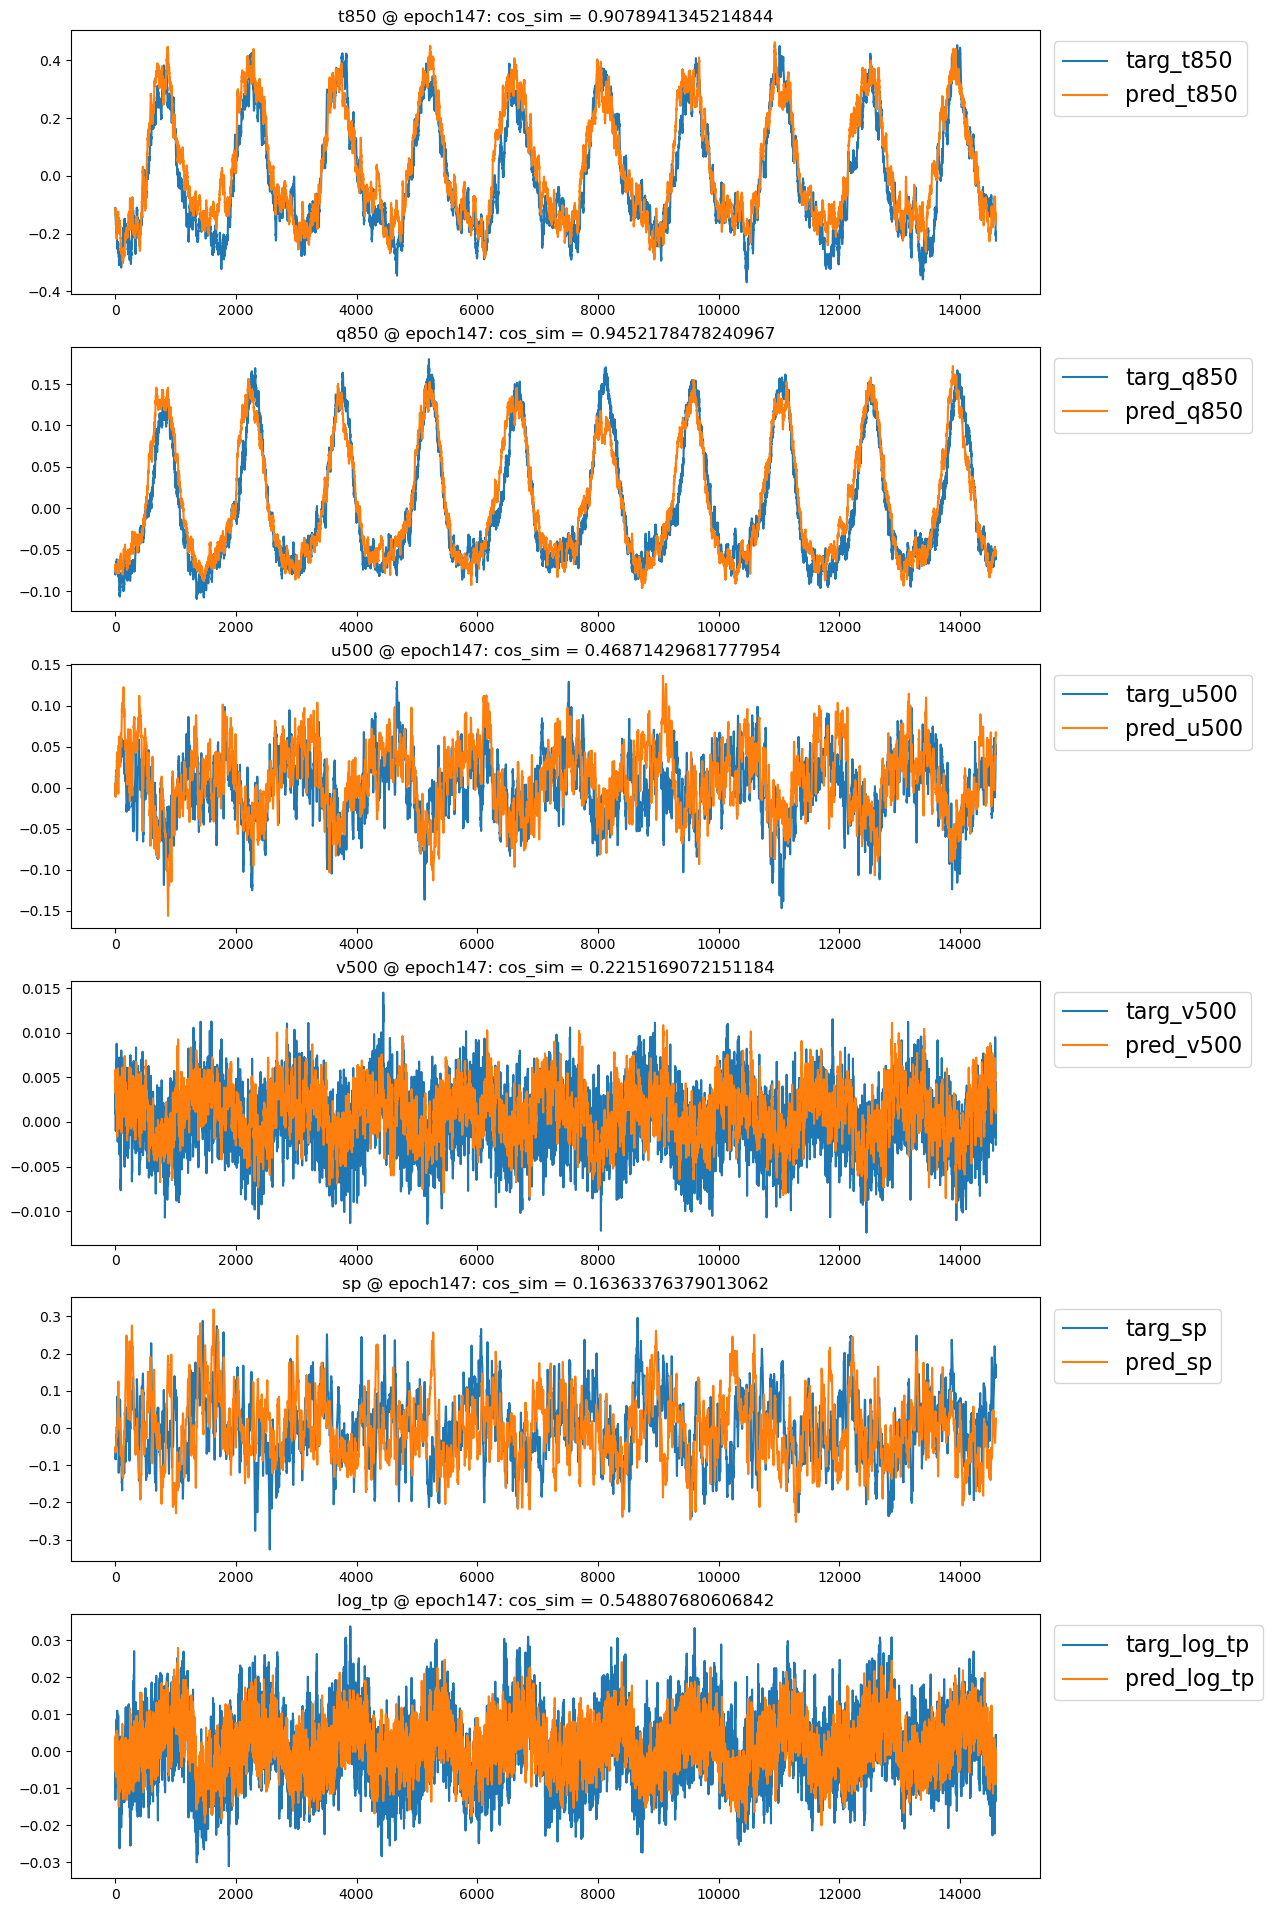

In [29]:
#jobid="145367077"
# ei="147"
true_clim_t = torch.mean(tt,dim=(-1,-2))
pred_clim_t = torch.mean(pp,dim=(-1,-2))
fig,axs = plt.subplots(nvars,1, figsize=(w*2.5,h*nvars))
for ii in range(nvars):
    pcm1 = axs[ii].plot(true_clim_t[:,ii],label=f"targ_{vars[ii]}")
    pcm2 = axs[ii].plot(pred_clim_t[:,ii],label=f"pred_{vars[ii]}")
    ppi = pred_clim_t[1460:,ii].reshape(1, -1)
    tti = true_clim_t[1460:,ii].reshape(1, -1)
    cos_sim = cosine_similarity(ppi, tti)[0, 0]
    axs[ii].set_title(f"{vars[ii]} @ epoch{ei}: cos_sim = {cos_sim}")
    axs[ii].legend(loc='upper left', bbox_to_anchor=(1.003, 1),fontsize=16)

# The END